In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df=pd.read_csv('Datasets\Ice_cream selling data.csv')
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 912.0 bytes


In [8]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [9]:
df.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

In [10]:
df.duplicated().sum()

0

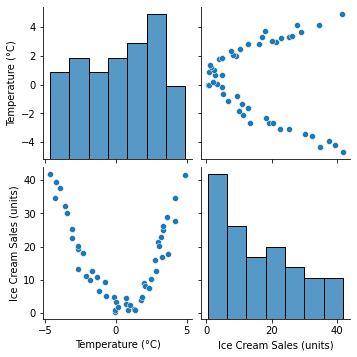

In [12]:
sns.pairplot(df)

In [16]:
y=df['Ice Cream Sales (units)']
x=df[['Temperature (°C)']]

In [17]:
print(x.shape)
print(y.shape)

(49, 1)
(49,)


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [19]:
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x_train)

In [20]:
model=LinearRegression()

In [21]:
model.fit(x_poly,y_train)

LinearRegression()

In [22]:
y_pred=model.predict(poly.fit_transform(x_test))

In [23]:
r2_score(y_test,y_pred)

0.9300570976550553

In [24]:
mean_squared_error(y_test,y_pred)

11.186143275103152

In [29]:
mse=[]
r2=[]
r2_s=0

for i in range(1,11):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)  
    poly=PolynomialFeatures(degree=i)
    x_poly=poly.fit_transform(x_train)
    model=LinearRegression()    
    model.fit(x_poly,y_train)
    y_pred=model.predict(poly.fit_transform(x_test))
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
    if r2_score(y_test,y_pred)>r2_s:
        y_4=model.predict(poly.fit_transform([[4]]))
        r2_s=r2_score(y_test,y_pred)
print(min(mse))
print(max(r2))
print(r2_s)
print(y_4)

8.055853874925686
0.9496296635022425
0.9496296635022425
[30.18722737]
